In [22]:
# import numpy as np
# # 7 Design of the hydraulic components

# # 7.1.2 Hydraulic specification

# # 7.1.2.1 Best efficient point (BEP)
# mdot_opt = 0.3  # kg/s, optimal mass flow rate
# rho_0 = 1000.0  # kg/m^3
# H_opt = 300.0   # m, head at BEP
# n = 30000 # rpm
# Q_opt = mdot_opt / rho_0 # m^3/s, optimal flow rate

# # 7.1.2.2
# Q_max = 1.1 * Q_opt # m^3/s, maximum flow rate

# # 7.1.2.3
# # NPSH_A = ??

# # 7.1.3, channel model

# #STEP 1
# n_q = n * np.sqrt(Q_opt) / np.pow(H_opt, 0.75)  # Specific speed
# A_v = (42 + 53) * 0.5 / n_q # Area ratio 7.1.3.1

# #STEP 2 
# head_coeff_th = np.pow(A_v, 0.23) # Theoretical head coefficient
# c3q_d_u2 = 0.31 * np.pow(A_v, 0.45) # c3q/u2, Average velocity in diffuser throat / Radial speed at impeller outlet

# #STEP 3
# #Estimate theoretical hydraulic efficiency with T3.9, radial pump single stage

# Q_ref = 1 # T.(3.9)
# m = 0.1 * 1 * np.pow(Q_ref / Q_opt, 0.15) * np.pow(45 / n_q, 0.06) # Efficiency Exponent Eq. (3.9.1)
# # eff_opt = 1 - 0.095 * np.pow(Q_ref/ Q_opt, m) - 0.3 * np.pow(0.35 - np.log10(n_q / 23), 2) * np.pow(Q_ref / Q_opt, 0.05) # Overall efficiency of single stage radial pump Eq.(3.9.1), might not be applicable above Q>0.005, for 0.0005 gives negative so it can't be used.
# eff_opt = 0.4 #Table 2.3, lowest number

# eff_h_opt = 0.5 * (1 + eff_opt) # Approximation for small pumps and partlead Eq.(3.28a) Apprently this equation is good for even Q=0 and partload.

# m_h = 0.08 * np.pow(Q_ref / Q_opt, 0.08) * (1 - eff_opt)
# eff_h_opt2 = 1 - 0.055 * np.pow(Q_ref/ Q_opt, m_h) - 0.2 * np.pow(0.26 - np.log10(n_q / 25), 2) * np.pow(Q_ref / Q_opt, 0.1) # Hydraulic efficiency of single stage radial pumpss Eq.(3.9.1), might not be applicable above Q>0.005 but nothing else can be done
# eff_h_opt = min(eff_h_opt, eff_h_opt2)  # Take the minimum of the two estimates


# head_coeff_opt = eff_h_opt * head_coeff_th  # Head coefficient 7.1.3.3

# g = 9.81  # m/s^2, gravitational acceleration
# d_2 = 60 / (np.pi * n) * np.sqrt(2 * g * H_opt / head_coeff_opt) # Impeller outlet diameter Eq.(7.1.3)
# u_2 = np.pi * d_2 * n / 60  # Radial speed at r=d2/2
# c3q = u_2 * c3q_d_u2

# #STEP 4
# z_Le = 1 # Number of diffuser vanes or volute channels, doesn't really make sense for an annular volute, Le is volute, La is Laufrad or impelelr in english.
# A_3q = Q_opt / (z_Le * c3q) # Throat area of diffuser

# #STEP 5
# # Relative outlet width b2star
# lognq = np.log10(n_q)
# b2star = np.pow(10, -0.2 * lognq * lognq + 1.35 * lognq - 2.6) # Fig 7.2, quadratic regression from https://www.desmos.com/calculator/l44pulw06b, better than given 7.1 cubic fit

# z_La = 6 # Number of impeller blades
# A_2q = A_v * z_Le * A_3q / z_La # Area between vanes at impeller outlet 7.1.3.5
# b_2 = A_2q / d_2 # It says d_2a in fig 7.2 and 7.2.1.9, subscripts say a means outer streamline, but I don't know how to calculate that.

# #STEP 6
# a_2 = A_2q / b_2

# Sizing using 7.2.1 Determination of main dimensions
import numpy as np

# 7.2.1.1 Boundary conditions
mdot_opt = 0.3  # kg/s, optimal mass flow rate
rho_0 = 1000.0  # kg/m^3
H_opt = 200.0   # m, head at BEP
n = 20000 # rpm
Q_opt = mdot_opt / rho_0 # m^3/s, optimal flow rate
n_q = n * np.sqrt(Q_opt) / np.power(H_opt, 0.75)  # Specific speed


# 7.2.1.2 Efficiencies estimation.
# eff_opt = 0.2 #Table 2.3, lowest number, where the hell did I get this number?
# eff_h_opt = 0.5 * (1 + eff_opt)

Q_ref = 1 # T.(3.9)
eff_opt = 0.4 #Table 2.3, lowest number, found in Table 2.3 Pump Types nq 7-30 radial pumps, 40-88%

# m = 0.1 * 1 * np.pow(Q_ref / Q_opt, 0.15) * np.pow(45 / n_q, 0.06) # Efficiency Exponent Eq. (3.9.1)
# eff_opt = 1 - 0.095 * np.pow(Q_ref/ Q_opt, m) - 0.3 * np.pow(0.35 - np.log10(n_q / 23), 2) * np.pow(Q_ref / Q_opt, 0.05) # Overall efficiency of single stage radial pump Eq.(3.9.1), might not be applicable above Q<0.005, for 0.0005 gives negative so it can't be used.

eff_h_opt = 0.5 * (1 + eff_opt) # Approximation for small pumps and partlead Eq.(3.28a) Apprently this equation is good for even Q=0 and partload.

m_h = 0.08 * np.pow(Q_ref / Q_opt, 0.08) * (1 - eff_opt)
eff_h_opt2 = 1 - 0.055 * np.pow(Q_ref/ Q_opt, m_h) - 0.2 * np.pow(0.26 - np.log10(n_q / 25), 2) * np.pow(Q_ref / Q_opt, 0.1) # Hydraulic efficiency of single stage radial pumpss Eq.(3.9.1), might not be applicable above Q>0.005 but nothing else can be done
# eff_h_opt = min(eff_h_opt, eff_h_opt2)  # Take the minimum of the two estimates

# This equation above gives 0.56, where eq3.28a gives 0.7. As 3.28a is for small pumps, I will use it.


# 7.2.1.3 Shaft diameter
d_w = 0.01 # 1cm shaft, eq 7.1.2 gives 6mm so this gives a safety factor.

# 7.2.1.4 Impeller outer diameter d2
psi_coeff_opt = 1.21 * np.exp(-0.77 * n_q / 100) # Head coefficient Eq.(3.26), best fit from Fig 3.24.

d_2 = 60 / (np.pi * n) * np.sqrt(2 * 9.81 * H_opt / psi_coeff_opt)  # Impeller outlet diameter Eq.(7.1.3)
d_2 = 0.062

#7.2.1.5 Blade number
z_La = 6 # Just for now!! Many requirements play into this, I haven't read

#7.2.1.6 Impeller inlet diameter
#Sized with method A, minimum relative velocity at impeller inlet

# For this section alpha1, swirl is repeatedly used, 7.2.1.1 says alpha1 = 90 is assumed constant at the first iteration, so I will assume that for now.
alpha_1 = np.deg2rad(90) # Inlet flow angle, 90 means purely radial, no swirl

d_n_star = 0.007/d_2 # Hub diameter, just a placeholder for a m4 screw head
delta_r = 1 # Swirl number Eq.(T.7.1.4) (assuming alpha 1 = 90)
f_d_1 = 1.2 # Eq.(T.7.1.4)
d_1_star = f_d_1 * np.sqrt(d_n_star * d_n_star + 1.5e-3 * psi_coeff_opt * np.pow(n_q, 1.33) / np.pow(delta_r, 0.67))

# d_1_star = 0.025 / d_2
d_1 = d_1_star * d_2

# Method B: Select suction specific speed
# Method C: lambda c and lambda w, need to read Chapter 6.3
# Method D: Minimum NPSH

#7.2.1.7 Blade Inlet Diameter
d_1_i = d_1 #for now...?

#7.2.1.8 Impeller blade inlet angles

#Inlet velocity triangle T3.1

# For this section alpha1, swirl is repeatedly used, 7.2.1.1 says alpha1 = 90 is assumed constant at the first iteration, so I will assume that for now. Maybe this will change after the first iteration.
alpha_1 = np.deg2rad(90) # Inlet flow angle, 90 means purely radial, no swirl

u_1 = np.pi * d_1 * n / 60 # T3.1.1 # Circumferential speed at impeller inlet
d_n = d_n_star * d_2  # Hub diameter, from definition of star being nondimensional to d_2
A_1 = np.pi / 4 * (d_1 ** 2 - d_n ** 2)  # Area at impeller inlet # T3.1.2
fq = 1 # Number of impeller eyes, single entry so 1
c_1m = Q_opt / (A_1 * fq)  # Meridional velocity # T3.1.2
c_1u = 0 # Assumed zero for now, no swirl at inlet # T3.1.3
w_1 = np.sqrt(c_1m ** 2 + (u_1 - c_1u) ** 2)  # Relative velocity # T3.1.4
phi_1 = c_1m / u_1 # Flow coefficient # T1.5
beta_1 = np.arctan(c_1m / (u_1 - c_1u)) # Flow angle without blockage # T3.1.6


# This seems to be an implicit equation between tau_1 and beta_1, I will solve as so:
# Assume no blockage
e = 0.022 * d_2 # Blade thickness according to 7.1.2.11 for up to 600m head
e_1 = e * 0.5 # just a guess for now
# Note: in Table 3.1 it recommends a lower leading edge e_1 than e, the thickness of the whole blade. Lower this if blockage is too high.
i_1 = np.deg2rad(0) # Choose incidence = 0 for now, I don't know how to select it according to 7.1.2.8
beta_1_B = beta_1 + i_1 # T3.1.9 Blade angle
lambda_la = np.deg2rad(90) # Twist of the angle, assume 90 for now, no twist
tau_1 = 1 / (1 - (z_La * e_1)/(np.pi * d_1 * np.sin(beta_1_B) * np.sin(lambda_la))) # Blade blockage correction factor, T3.1.7
beta_1_blockage = 0 # Placeholder to make intellisense happy
for _ in range(10):
    beta_1_blockage = np.arctan(c_1m * tau_1 / (u_1 - c_1u)) # Flow angle with blockage, T3.1.8
    tau_1 = 1 / (1 - (z_La * e_1)/(np.pi * d_1 * np.sin(beta_1_blockage + i_1) * np.sin(lambda_la))) # Update blockage correction factor with new angle, T3.1.7

beta_1_B = beta_1_blockage + i_1 # Final blade angle with blockage, T3.1.9
phi_1_sf = (1 - c_1u/u_1) * np.tan(beta_1_B) / tau_1 # SF = shockless flow, at inlet, T3.1.10
Q_1_max_sf = A_1 * fq * u_1 * phi_1_sf # Maximum shockless flow just to check

# This should be done for every streamline, but for now I will assume 1D. I assume the thing that changes is lambda only...?

#7.2.1.9 Outlet width b2
lognq = np.log10(n_q)
b_2star = np.pow(10, -0.2 * lognq * lognq + 1.35 * lognq - 2.6) # Fig 7.2, quadratic regression from https://www.desmos.com/calculator/l44pulw06b, better than given 7.1 cubic fit
b_2 = b_2star * d_2

#7.2.1.10 Outlet angle

# Multi step optimization, so I will assume a starting (beta_2B, b_2)and change until all criteria are fulfilled.

# Guesses:
beta_2B = np.deg2rad(35)
b_2 = 1.8

# # T7.1.8 and T3.2.4 for both epsilon and k_w
# # Meaning: Influence of impeller inlet diameter on slip factor
# epsilon_lim = np.exp(-8.16 * np.sin(beta_2B) / z_La) 
# if epsilon_lim > d_1_star:
#     k_w = 1
# else:
#     k_w = 1 - np.pow((d_1_star - epsilon_lim) / (1 - epsilon_lim), 3)
# f1 = 0.98 # For radial impellers T7.1.8
# gamma = f1 * (1 - np.sqrt(np.sin(beta_2B)) / z_La**0.7) * k_w # Slip factor T7.1.8
# # T7.1.9
# A_2 = np.pi * d_2 * b_2
u_2 = np.pi * d_2 * n / 60 

# head_coeff_1 = Q_opt / (fq * A_2 * u_2 * np.tan(beta_2B))
# head_coeff_2 = 0 #(A_2 * d_1_star * np.tan(beta_2B)) / (A_1 * np.tan(alpha_1)) # T7.1.9, alpha in denominator=0
# tau_2 = 1 / (1 - (z_La * e)/(np.pi * d_2 * np.sin(beta_2B) * np.sin(lambda_la))) # Blade blockage correction factor at outlet, T3.2.3
# g = 9.81
# head_from_b2b = eff_h_opt * u_2**2 / g * (gamma - head_coeff_1 * (tau_2 + head_coeff_2)) # T7.1.9, head from b2 and beta2, should be close to H_opt

# c_2m = Q_opt / (fq * A_2) # Meridional component of absolute velocity at outlet, T3.2.2
# c_2u = u_2 * (gamma - (c_2m * tau_2) / (u_2 * np.tan(beta_2B))) # T3.2.7, circumferential component of aboslute velocity at outlet prediction. 

# # After measuring real, use:
# # T3.2.8: Calculated c2u from omeasured head H
# # T3.2.9: Real slip factor from test
# c_2 = np.sqrt(c_2m**2 + c_2u**2) # T3.2.10, absolute velocity at outlet
# w_2u = u_2 - c_2u # T3.2.11, circumferential component of relative velocity at outlet
# w_2 = np.sqrt(c_2m**2 + w_2u**2) # T3.2.12, relative velocity at outlet
# alpha_2 = np.arctan(c_2m / c_2u) # T3.2.13, absolute outlet angle without blockage
# beta_2 = np.arctan(c_2m / w_2u) # T3.2.14, relative outlet angle without blockage
# beta_2_blockage = np.arctan(c_2m * tau_2 / w_2u) # T3.2.15, relative outlet angle with blockage
# delta_2 = beta_2B - beta_2 # 7.1.10 Deviation angle, should not exceed 10-14

# from scipy.optimize import minimize
# # 7.2.1.10 Outlet optimization (beta_2B and b_2)

# # We need to package the outlet math into a function that Scipy can evaluate over and over.
# def evaluate_outlet(x):
#     # Unpack variables
#     beta_2B_guess = x[0]
#     b_2_guess = x[1]
    
#     # 1. Slip Factor
#     epsilon_lim = np.exp(-8.16 * np.sin(beta_2B_guess) / z_La) 
#     if d_1_star <= epsilon_lim:
#         k_w = 1.0
#     else:
#         k_w = 1.0 - np.power((d_1_star - epsilon_lim) / (1.0 - epsilon_lim), 3)
        
#     f1 = 0.98
#     gamma = f1 * (1 - np.sqrt(np.sin(beta_2B_guess)) / z_La**0.7) * k_w
    
#     # 2. Areas and Velocities
#     A_2 = np.pi * d_2 * b_2_guess
#     c_2m = Q_opt / (fq * A_2)
    
#     # 3. Blockage and Head
#     head_coeff_1 = Q_opt / (fq * A_2 * u_2 * np.tan(beta_2B_guess))
#     head_coeff_2 = 0
#     tau_2 = 1 / (1 - (z_La * e)/(np.pi * d_2 * np.sin(beta_2B_guess) * np.sin(lambda_la)))
    
#     calc_head = eff_h_opt * u_2**2 / 9.81 * (gamma - head_coeff_1 * (tau_2 + head_coeff_2))
    
#     # 4. Velocity Triangle & Angles
#     c_2u = u_2 * (gamma - (c_2m * tau_2) / (u_2 * np.tan(beta_2B_guess)))
#     w_2u = u_2 - c_2u
#     w_2 = np.sqrt(c_2m**2 + w_2u**2)
#     beta_2 = np.arctan(c_2m / w_2u)
#     delta_2 = beta_2B_guess - beta_2
    
#     return calc_head, delta_2, w_2

# # Objective function: Minimize the squared difference between calculated head and target head
# def objective(x):
#     calc_head, _, _ = evaluate_outlet(x)
#     return (calc_head - H_opt)**2

# # Constraint functions (SLSQP expects constraints to be >= 0)
# def constraint_deviation_min(x):
#     _, delta_2, _ = evaluate_outlet(x)
#     return np.rad2deg(delta_2) - 10.0  # delta_2 >= 10

# def constraint_deviation_max(x):
#     _, delta_2, _ = evaluate_outlet(x)
#     return 14.0 - np.rad2deg(delta_2)  # delta_2 <= 14

# def constraint_de_haller(x):
#     _, _, w_2_calc = evaluate_outlet(x)
#     return (w_2_calc / w_1) - 0.7      # w_2 / w_1 >= 0.7

# # Setup the optimizer
# # Initial guesses: [beta_2B in rads (15 deg), b_2 in meters (~1.3mm)]
# x0 = [np.deg2rad(15), b_2star * d_2]

# # Bounds: Keep beta_2B between 10 and 35 degrees, and b_2 between 0.5mm and 5mm
# bounds = [
#     (np.deg2rad(10), np.deg2rad(35)), 
#     (0.0005, 0.01)
# ]

# # Dictionary of constraints for scipy
# cons = [
#     {'type': 'ineq', 'fun': constraint_deviation_min},
#     {'type': 'ineq', 'fun': constraint_deviation_max},
#     {'type': 'ineq', 'fun': constraint_de_haller}
# ]

# # Run the optimization!
# result = minimize(objective, x0, method='SLSQP', bounds=bounds, constraints=cons)

# if not result.success:
#     # print("\n--- Optimization Successful! ---")
# # else:
#     print(f"\n--- Optimization Failed: {result.message} ---")

# # Extract the optimized values and run the math one last time to populate your global variables
# beta_2B = result.x[0]
# b_2 = result.x[1]

# Re-run the geometry with the optimized values so your print statements at the bottom work
A_2 = np.pi * d_2 * b_2
epsilon_lim = np.exp(-8.16 * np.sin(beta_2B) / z_La) 
if d_1_star <= epsilon_lim:
    k_w = 1.0
else:
    k_w = 1.0 - np.power((d_1_star - epsilon_lim) / (1.0 - epsilon_lim), 3)

f1 = 0.98 
gamma = f1 * (1 - np.sqrt(np.sin(beta_2B)) / z_La**0.7) * k_w 
tau_2 = 1 / (1 - (z_La * e)/(np.pi * d_2 * np.sin(beta_2B) * np.sin(lambda_la))) 
head_coeff_1 = Q_opt / (fq * A_2 * u_2 * np.tan(beta_2B))
head_from_b2b = eff_h_opt * u_2**2 / 9.81 * (gamma - head_coeff_1 * (tau_2 + 0)) 

c_2m = Q_opt / (fq * A_2) 
c_2u = u_2 * (gamma - (c_2m * tau_2) / (u_2 * np.tan(beta_2B))) 
c_2 = np.sqrt(c_2m**2 + c_2u**2) 
w_2u = u_2 - c_2u 
w_2 = np.sqrt(c_2m**2 + w_2u**2) 
alpha_2 = np.arctan(c_2m / c_2u) 
beta_2 = np.arctan(c_2m / w_2u) 
beta_2_blockage = np.arctan(c_2m * tau_2 / w_2u) 
delta_2 = beta_2B - beta_2

power = mdot_opt * 9.81 * H_opt / eff_opt

print(f"Boundary conditions:")
print(f"  {"Mass flow rate (mdot)":<60} {mdot_opt:<10.4g} kg/s")
print(f"  {"Outlet Head (H)":<60} {H_opt:<10.4g} m")
print(f"  {"Rotational speed (n)":<60} {n:<10.1g} rpm")
print(f"  {"Flow rate (Q)":<60} {Q_opt:<10.4g} m^3/s")
print(f"  {"Specific speed (n_q)":<60} {n_q:<10.4g}")
print(f"Outputs:")
print(f"  {"Efficiency":<60} {eff_opt:<10.4g}")
print(f"  {"Hydraulic efficiency":<60} {eff_h_opt:<10.4g}")
print(f"  {"Head coefficient":<60} {psi_coeff_opt:<10.4g}")
print(f"  {"Impeller outlet diameter (d2)":<60} {d_2*1000:<10.4g} mm")
print(f"  {"Impeller inlet diameter (d1)":<60} {d_1*1000:<10.4g} mm")
print(f"  {"Power required (P)":<60} {power:<10.4g} W")
print(f"  {'Blade thickness (e1)':<60} {e_1*1000:<10.4g} mm")
print(f"  {'Hub diameter (d_n)':<60} {d_n*1000:<10.4g} mm")
print(f"  {'Inlet flow angle (alpha_1)':<60} {np.rad2deg(alpha_1):<10.4g} degrees")
print(f"  {'Meridional vel at inlet (c_1m)':<60} {c_1m:<10.4g} m/s")
print(f"  {'Circm vel at inlet (u_1)':<60} {u_1:<10.4g} m/s")
print(f"  {'Circm component of abs vel at inlet (c_1u)':<60} {c_1u:<10.4g} m/s")
print(f"  {'Relative vel at inlet (w_1)':<60} {w_1:<10.4g} m/s")
print(f"  {'Flow coefficient at inlet (phi_1)':<60} {phi_1:<10.4g}")
print(f"  {'Flow angle at inlet w/o blockage (beta_1)':<60} {np.rad2deg(beta_1):<10.4g} degrees")
print(f"  {'Blade angle at inlet w/o blockage (beta_1B)':<60} {np.rad2deg(beta_1 + i_1):<10.4g} degrees")
print(f"  {'Blade thickness':<60} {e_1*1000:<10.4g} mm")
print(f"  {'Blade blockage correction factor (tau_1)':<60} {tau_1:<10.4g}")
print(f"  {'Flow angle at inlet with blockage (beta_1_blockage)':<60} {np.rad2deg(beta_1_blockage):<10.4g} degrees")
print(f"  {'Blade angle at inlet (beta_1B)':<60} {np.rad2deg(beta_1_B):<10.4g} degrees")
print(f"  {'Shockless phi at inlet (phi_1_sf)':<60} {phi_1_sf:<10.4g}")
print(f"  {'Max shockless mdot inlet':<60} {Q_1_max_sf*1000:<10.4g} kg/s")
print(f"Outlet conditions checking:")
print(f"  {'Guess beta_2B':<60} {np.rad2deg(beta_2B):<10.4g} degrees")
print(f"  {'Guess b_2':<60} {b_2*1000:<10.4g} mm")
print(f"  {'Blockage correction factor at outlet (tau_2)':<60} {tau_2:<10.4g}")
print(f"  {'Slip factor (gamma)':<60} {gamma:<10.4g}")
print(f"  {'Head from b2 and beta2 (head_from_b2b)':<60} {head_from_b2b:<10.4g} m")
print(f"  {'Meridional vel at outlet (c_2m)':<60} {c_2m:<10.4g} m/s")
print(f"  {'Circm vel at outlet (c_2u)':<60} {c_2u:<10.4g} m/s")
print(f"  {'Absolute vel at outlet (c_2)':<60} {c_2:<10.4g} m/s")
print(f"  {'Circm component of relative vel at outlet (w_2u)':<60} {w_2u:<10.4g} m/s")
print(f"  {'Relative vel at outlet (w_2)':<60} {w_2:<10.4g} m/s")
print(f"  {'Flow angle at outlet w/o blockage (beta_2)':<60} {np.rad2deg(beta_2):<10.4g} degrees")
print(f"  {'Blade angle at outlet w/o blockage (beta_2B)':<60} {np.rad2deg(beta_2B):<10.4g} degrees")
print(f"  {'Flow angle at outlet with blockage (beta_2_blockage)':<60} {np.rad2deg(beta_2_blockage):<10.4g} degrees")
print(f"  {'Deviation angle (delta_2)':<60} {np.rad2deg(delta_2):<10.4g} degrees")

print(f"Criteria checking:")
print(f"  {'Deviation angle should be less than 10-14 degrees':<60} {np.rad2deg(delta_2) < 14} => {np.rad2deg(delta_2):<10.4g}")
print(f"  {'De haller number should be above  0.7':<60} {w_2 / w_1 > 0.7} => {w_2 / w_1:<10.4g}")
print(f"  {'Calculated head should be close to target head':<60} {abs(head_from_b2b - H_opt) / H_opt < 0.05} => {head_from_b2b:<10.4g} m")



Boundary conditions:
  Mass flow rate (mdot)                                        0.3        kg/s
  Outlet Head (H)                                              200        m
  Rotational speed (n)                                         2e+04      rpm
  Flow rate (Q)                                                0.0003     m^3/s
  Specific speed (n_q)                                         6.514     
Outputs:
  Efficiency                                                   0.4       
  Hydraulic efficiency                                         0.7       
  Head coefficient                                             1.151     
  Impeller outlet diameter (d2)                                62         mm
  Impeller inlet diameter (d1)                                 13.64      mm
  Power required (P)                                           1472       W
  Blade thickness (e1)                                         0.682      mm
  Hub diameter (d_n)                                  

In [27]:
import numpy as np

# 1. Boundary conditions
mdot_opt = 0.3  # kg/s
rho_0 = 1000.0  # kg/m^3
H_opt = 200.0   # m
n = 20000       # rpm
Q_opt = mdot_opt / rho_0 # m^3/s
n_q = n * np.sqrt(Q_opt) / np.power(H_opt, 0.75)  # Specific speed

# 2. CFturbo Forced Efficiencies
eff_h_opt = 0.50   # Hydraulic efficiency (50%)
eff_v = 1.0        # Volumetric efficiency (100%)
eff_m = 0.947      # Mechanical efficiency (94.7%)
eff_s = 0.64       # Side friction efficiency (64%)
eff_mot = 0.80     # Motor efficiency (80%)

# Total pump efficiency (excluding motor)
eff_opt = eff_h_opt * eff_v * eff_m * eff_s 

# 3. CFturbo Forced Geometry
d_2 = 0.063             # Impeller outer diameter (63 mm)
b_2 = 0.001858          # Outlet width (1.858 mm)
beta_2B = np.deg2rad(29.4) # Blade angle at outlet (29.4 deg)
d_1 = 0.01492           # Suction diameter (14.92 mm)
d_n = 0.0074            # Hub diameter (7.4 mm)
z_La = 6                # Number of blades
e = 0.0009              # Blade thickness (0.9 mm from your previous CFturbo data)

# 4. Inlet Calculations
u_1 = np.pi * d_1 * n / 60 
A_1 = np.pi / 4 * (d_1 ** 2 - d_n ** 2)  
c_1m = Q_opt / A_1 
c_1u = 0 # No pre-swirl
w_1 = np.sqrt(c_1m ** 2 + (u_1 - c_1u) ** 2) 

# 5. Outlet Calculations
A_2 = np.pi * d_2 * b_2
u_2 = np.pi * d_2 * n / 60 
c_2m = Q_opt / A_2 

# Slip Factor (Gülich/Wiesner formulation)
d_1_star = d_1 / d_2
epsilon_lim = np.exp(-8.16 * np.sin(beta_2B) / z_La) 

if d_1_star <= epsilon_lim:
    k_w = 1.0
else:
    k_w = 1.0 - np.power((d_1_star - epsilon_lim) / (1.0 - epsilon_lim), 3)

f1 = 0.98 
gamma = f1 * (1 - np.sqrt(np.sin(beta_2B)) / z_La**0.7) * k_w 

# Blockage Calculation
lambda_la = np.deg2rad(90) # Assuming straight blades axially at outlet
tau_2 = 1 / (1 - (z_La * e)/(np.pi * d_2 * np.sin(beta_2B) * np.sin(lambda_la))) 

# Velocity Triangles at Outlet
c_2u = u_2 * (gamma - (c_2m * tau_2) / (u_2 * np.tan(beta_2B))) 
w_2u = u_2 - c_2u 
w_2 = np.sqrt(c_2m**2 + w_2u**2) 
c_2 = np.sqrt(c_2m**2 + c_2u**2)

alpha_2 = np.arctan(c_2m / c_2u) 
beta_2 = np.arctan(c_2m / w_2u) 
delta_2 = beta_2B - beta_2 

# Euler Head Calculation to verify it hits ~200m with CFturbo's 50% efficiency
head_calc = (eff_h_opt * u_2 * c_2u) / 9.81

# Power Calculation
power_hydraulic = mdot_opt * 9.81 * H_opt
power_shaft = power_hydraulic / eff_opt

print(f"--- CFturbo Matched 1D Output ---")
print(f"Target Head:             {H_opt:.2f} m")
print(f"Calculated 1D Head:      {head_calc:.2f} m")
print(f"Overall Efficiency:      {eff_opt*100:.2f} %")
print(f"Shaft Power Required:    {power_shaft:.2f} W")
print("-" * 33)
print(f"Tip Speed (u_2):         {u_2:.2f} m/s")
print(f"Meridional Vel (c_2m):   {c_2m:.2f} m/s")
print(f"Tangential Vel (c_2u):   {c_2u:.2f} m/s")
print(f"Absolute Vel (c_2):      {c_2:.2f} m/s")
print(f"Relative Vel (w_2):      {w_2:.2f} m/s")
print("-" * 33)
print(f"Flow Angle (alpha_2):    {np.rad2deg(alpha_2):.2f} deg")
print(f"Rel Flow Angle (beta_2): {np.rad2deg(beta_2):.2f} deg")
print(f"Deviation (delta_2):     {np.rad2deg(delta_2):.2f} deg")
print(f"De Haller Number:        {w_2 / w_1:.3f}")
print("-" * 33)
print(f"Blade inlet angle:  {np.rad2deg(beta_1_B):.2f} deg")
print(f"Blade exit angle:    {np.rad2deg(beta_2B):.2f} deg")

--- CFturbo Matched 1D Output ---
Target Head:             200.00 m
Calculated 1D Head:      168.79 m
Overall Efficiency:      30.30 %
Shaft Power Required:    1942.32 W
---------------------------------
Tip Speed (u_2):         65.97 m/s
Meridional Vel (c_2m):   0.82 m/s
Tangential Vel (c_2u):   50.20 m/s
Absolute Vel (c_2):      50.20 m/s
Relative Vel (w_2):      15.80 m/s
---------------------------------
Flow Angle (alpha_2):    0.93 deg
Rel Flow Angle (beta_2): 2.96 deg
Deviation (delta_2):     26.44 deg
De Haller Number:        1.001
---------------------------------
Blade inlet angle:  16.41 deg
Blade exit angle:    29.40 deg


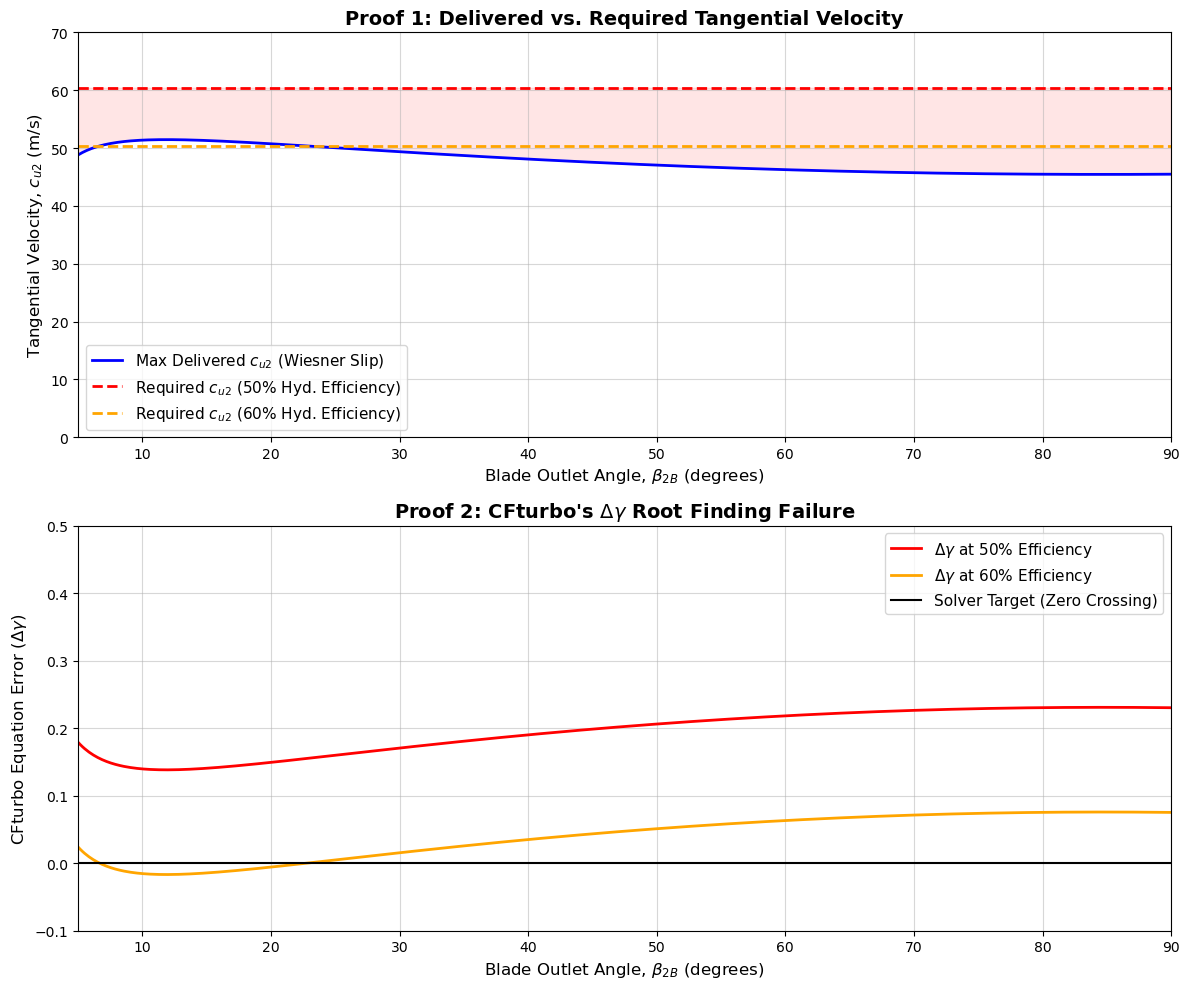

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Global Boundary Conditions
H = 200.0        # Target Head (m)
Q = 0.0003       # Flow rate (m^3/s)
n = 20000        # RPM
g = 9.81         # Gravity (m/s^2)

# 2. CFturbo / Conventional Geometry Baseline
d2 = 0.062       # Impeller diameter (m)
b2 = 0.001858    # Impeller width (m)
z = 6            # Number of blades

# 3. Velocity and Kinematics
u2 = np.pi * d2 * n / 60
cm2 = Q / (np.pi * d2 * b2)

# 4. Blade Angle Sweep (From extremely shallow 5 deg to straight radial 90 deg)
beta2B_deg = np.linspace(5, 90, 500)
beta2B_rad = np.radians(beta2B_deg)

# ==========================================
# MATHEMATICAL PROOF 1: THE EULER MISMATCH
# ==========================================

# Required cu2 based on Euler's Pump Equation for different hydraulic efficiencies
# H = (eta_h * u2 * cu2) / g  =>  cu2_req = (g * H) / (eta_h * u2)
cu2_req_50 = (g * H) / (0.50 * u2)  # CFturbo's internal efficiency penalty
cu2_req_60 = (g * H) / (0.60 * u2)  # A highly optimistic penalty

# Maximum Delivered cu2 based on kinematic guidance and Wiesner Slip
# We assume kw = 1.0 (best-case scenario, assuming perfect blade length)
f1 = 0.98
gamma_wiesner = f1 * (1 - np.sqrt(np.sin(beta2B_rad)) / (z**0.7))

# Actual tangential velocity delivered after slip and geometric backward sweep
cu2_delivered = (u2 * gamma_wiesner) - (cm2 / np.tan(beta2B_rad))

# ==========================================
# MATHEMATICAL PROOF 2: CFTURBO'S FAILURE
# ==========================================

# CFturbo's internal solver tries to find where Delta Gamma crosses 0.
# Delta Gamma = cm2 / (u2 * tan(B2)) + (cu2_req / u2) - gamma_wiesner
delta_gamma_50 = (cm2 / (u2 * np.tan(beta2B_rad))) + (cu2_req_50 / u2) - gamma_wiesner
delta_gamma_60 = (cm2 / (u2 * np.tan(beta2B_rad))) + (cu2_req_60 / u2) - gamma_wiesner

# ==========================================
# PLOTTING
# ==========================================

plt.figure(figsize=(12, 10))

# --- Plot 1: The Euler vs Slip Mismatch ---
plt.subplot(2, 1, 1)
plt.plot(beta2B_deg, cu2_delivered, 'b-', linewidth=2, label="Max Delivered $c_{u2}$ (Wiesner Slip)")
plt.axhline(y=cu2_req_50, color='r', linestyle='--', linewidth=2, label="Required $c_{u2}$ (50% Hyd. Efficiency)")
plt.axhline(y=cu2_req_60, color='orange', linestyle='--', linewidth=2, label="Required $c_{u2}$ (60% Hyd. Efficiency)")

plt.title("Proof 1: Delivered vs. Required Tangential Velocity", fontsize=14, fontweight='bold')
plt.xlabel("Blade Outlet Angle, $\\beta_{2B}$ (degrees)", fontsize=12)
plt.ylabel("Tangential Velocity, $c_{u2}$ (m/s)", fontsize=12)
plt.xlim(5, 90)
plt.ylim(0, 70)
plt.grid(True, alpha=0.5)
plt.legend(fontsize=11)
plt.fill_between(beta2B_deg, cu2_delivered, cu2_req_50, where=(cu2_req_50 > cu2_delivered), color='red', alpha=0.1)

# --- Plot 2: CFturbo's Root Finding Failure ---
plt.subplot(2, 1, 2)
plt.plot(beta2B_deg, delta_gamma_50, 'r-', linewidth=2, label="$\\Delta\\gamma$ at 50% Efficiency")
plt.plot(beta2B_deg, delta_gamma_60, 'orange', linestyle='-', linewidth=2, label="$\\Delta\\gamma$ at 60% Efficiency")
plt.axhline(y=0, color='k', linestyle='-', linewidth=1.5, label="Solver Target (Zero Crossing)")

plt.title("Proof 2: CFturbo's $\\Delta\\gamma$ Root Finding Failure", fontsize=14, fontweight='bold')
plt.xlabel("Blade Outlet Angle, $\\beta_{2B}$ (degrees)", fontsize=12)
plt.ylabel("CFturbo Equation Error ($\\Delta\\gamma$)", fontsize=12)
plt.xlim(5, 90)
plt.ylim(-0.1, 0.5)
plt.grid(True, alpha=0.5)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

C:\Users\Martin\AppData\Local\Temp\ipykernel_53260\3083641856.py:51: RuntimeWarning: invalid value encountered in power
  gamma_base_AW * (1.0 - ((epsilon - eps_lim_AW)/(1.0 - eps_lim_AW))**np.sqrt(beta2B_deg/10.0)),


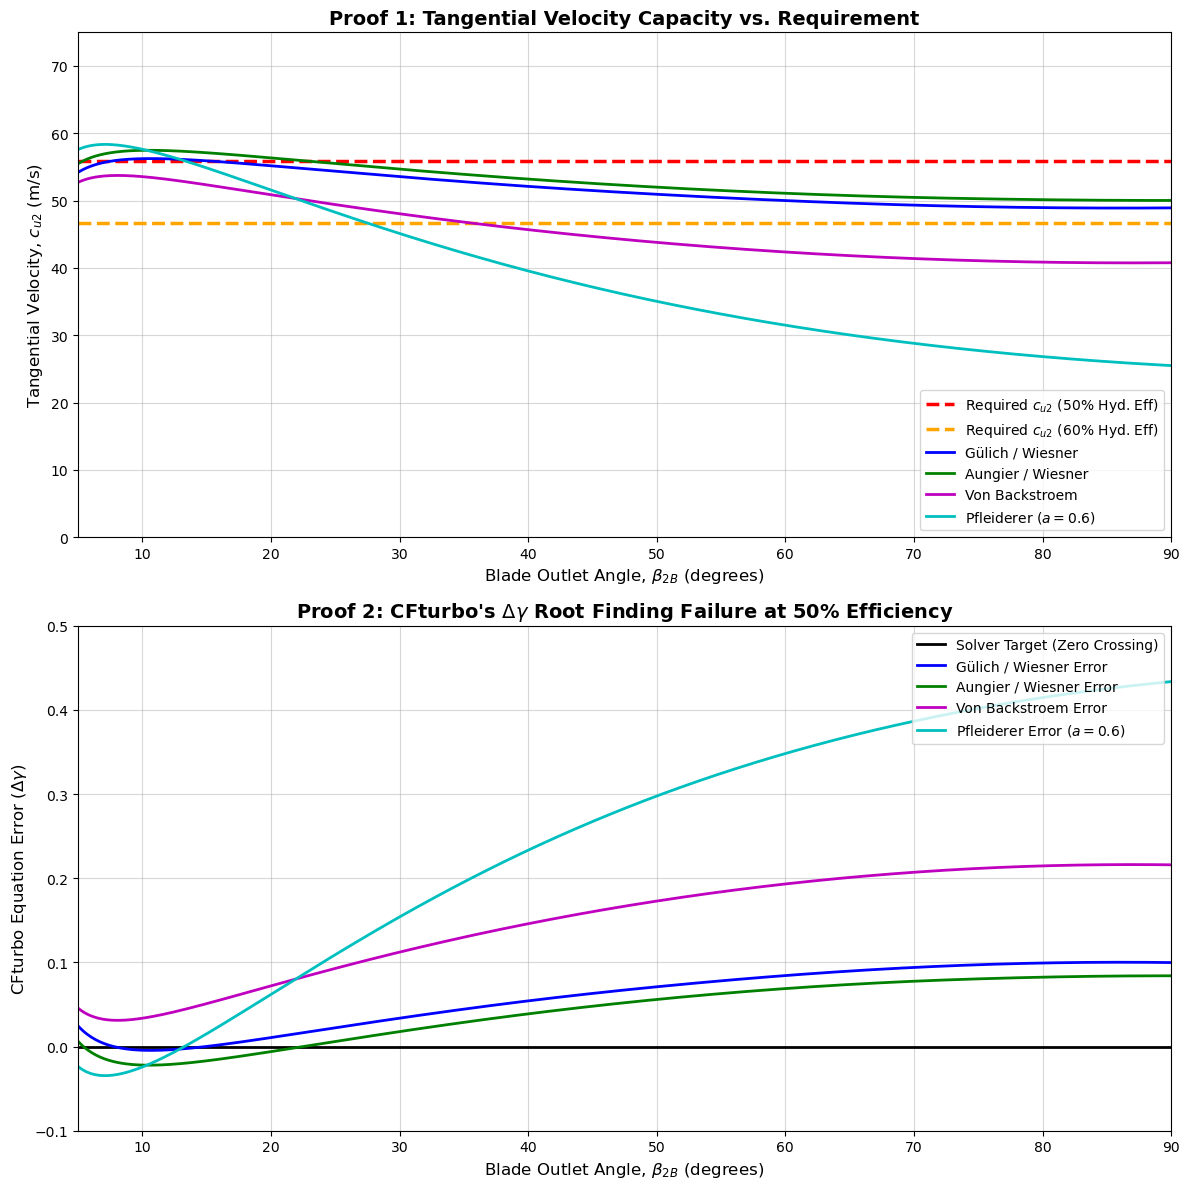

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Global Boundary Conditions
H = 200.0        # Target Head (m)
Q = 0.0003       # Flow rate (m^3/s)
n = 20000        # RPM
g = 9.81         # Gravity (m/s^2)

# 2. CFturbo / Conventional Geometry Baseline
d2 = 0.067       # Impeller outer diameter (m)
d_LE = 0.0254    # Impeller inlet (leading edge) diameter (m)
b2 = 0.001858    # Impeller width (m)
z = 6            # Number of blades

# 3. Velocity and Kinematics
u2 = np.pi * d2 * n / 60
cm2 = Q / (np.pi * d2 * b2)
epsilon = d_LE / d2  # Radius ratio

# 4. Blade Angle Sweep (From extremely shallow 5 deg to straight radial 90 deg)
beta2B_deg = np.linspace(5, 90, 500)
beta2B_rad = np.radians(beta2B_deg)

# ==========================================
# REQUIRED EULER TANGENTIAL VELOCITY
# ==========================================
cu2_req_50 = (g * H) / (0.50 * u2)  # CFturbo's realistic 50% penalty
cu2_req_60 = (g * H) / (0.60 * u2)  # An optimistic 60% penalty

# Theoretical kinematic velocity (without slip)
cu2_inf = u2 - cm2 / np.tan(beta2B_rad)

# ==========================================
# SLIP MODEL 1: GÜLICH / WIESNER
# ==========================================
f1 = 0.98
eps_lim_GW = np.exp(-8.16 * np.sin(beta2B_rad) / z)
kw_GW = np.where(epsilon <= eps_lim_GW, 1.0, 1.0 - ((epsilon - eps_lim_GW)/(1.0 - eps_lim_GW))**3)
gamma_GW = f1 * (1.0 - np.sqrt(np.sin(beta2B_rad)) / (z**0.7)) * kw_GW
cu2_GW = u2 * gamma_GW - cm2 / np.tan(beta2B_rad)

# ==========================================
# SLIP MODEL 2: AUNGIER / WIESNER
# ==========================================
gamma_base_AW = 1.0 - np.sqrt(np.sin(beta2B_rad)) / (z**0.7)
term_AW = np.sin(np.radians(19 + 0.2 * beta2B_deg))
eps_lim_AW = (gamma_base_AW - term_AW) / (1.0 - term_AW)
# Apply Aungier's correction if radius ratio exceeds limit
gamma_AW = np.where(epsilon > eps_lim_AW, 
                    gamma_base_AW * (1.0 - ((epsilon - eps_lim_AW)/(1.0 - eps_lim_AW))**np.sqrt(beta2B_deg/10.0)), 
                    gamma_base_AW)
cu2_AW = u2 * gamma_AW - cm2 / np.tan(beta2B_rad)

# ==========================================
# SLIP MODEL 3: VON BACKSTROEM
# ==========================================
eps_VB = max(epsilon, 0.5)
solidity_VB = (z * (1.0 - eps_VB)) / (2.0 * np.pi * np.sin(beta2B_rad))
gamma_VB = 1.0 - 1.0 / (5.0 * solidity_VB * np.sqrt(np.sin(beta2B_rad)))
cu2_VB = u2 * gamma_VB - cm2 / np.tan(beta2B_rad)

# ==========================================
# SLIP MODEL 4: PFLEIDERER
# ==========================================
# Static moment S (integration of r dx along the passage)
S_pf = (d2**2 - d_LE**2) / (8.0 * np.sin(beta2B_rad))
a_pf = 0.6  # Pfleiderer experience number from your CFturbo screenshot
psi_prime = a_pf * (1.0 + beta2B_deg / 60.0)
p_pf = psi_prime * ((d2/2.0)**2) / (2.0 * S_pf)
kL_pf = 1.0 / (1.0 + p_pf)
cu2_PF = cu2_inf * kL_pf

# Re-calculate Effective Gamma for Pfleiderer to use in the Delta Gamma plot
gamma_PF = 1.0 - (cu2_inf - cu2_PF) / u2

# ==========================================
# CFTURBO ROOT SOLVER ERRORS (Delta Gamma)
# ==========================================
# Delta Gamma = cm2 / (u2 * tan(B2)) + (cu2_req / u2) - gamma_model
term_1 = cm2 / (u2 * np.tan(beta2B_rad))
req_term_50 = cu2_req_50 / u2

dg_GW = term_1 + req_term_50 - gamma_GW
dg_AW = term_1 + req_term_50 - gamma_AW
dg_VB = term_1 + req_term_50 - gamma_VB
dg_PF = term_1 + req_term_50 - gamma_PF

# ==========================================
# PLOTTING
# ==========================================
plt.figure(figsize=(12, 12))

# --- Plot 1: Delivered c_u2 vs Required ---
plt.subplot(2, 1, 1)
plt.axhline(y=cu2_req_50, color='r', linestyle='--', linewidth=2.5, label="Required $c_{u2}$ (50% Hyd. Eff)")
plt.axhline(y=cu2_req_60, color='orange', linestyle='--', linewidth=2.5, label="Required $c_{u2}$ (60% Hyd. Eff)")

plt.plot(beta2B_deg, cu2_GW, 'b-', linewidth=2, label="Gülich / Wiesner")
plt.plot(beta2B_deg, cu2_AW, 'g-', linewidth=2, label="Aungier / Wiesner")
plt.plot(beta2B_deg, cu2_VB, 'm-', linewidth=2, label="Von Backstroem")
plt.plot(beta2B_deg, cu2_PF, 'c-', linewidth=2, label="Pfleiderer ($a=0.6$)")

plt.title("Proof 1: Tangential Velocity Capacity vs. Requirement", fontsize=14, fontweight='bold')
plt.xlabel("Blade Outlet Angle, $\\beta_{2B}$ (degrees)", fontsize=12)
plt.ylabel("Tangential Velocity, $c_{u2}$ (m/s)", fontsize=12)
plt.xlim(5, 90)
plt.ylim(0, 75)
plt.grid(True, alpha=0.5)
plt.legend(fontsize=10, loc='lower right')

# --- Plot 2: CFturbo's Delta Gamma Solver ---
plt.subplot(2, 1, 2)
plt.axhline(y=0, color='k', linestyle='-', linewidth=2, label="Solver Target (Zero Crossing)")

plt.plot(beta2B_deg, dg_GW, 'b-', linewidth=2, label="Gülich / Wiesner Error")
plt.plot(beta2B_deg, dg_AW, 'g-', linewidth=2, label="Aungier / Wiesner Error")
plt.plot(beta2B_deg, dg_VB, 'm-', linewidth=2, label="Von Backstroem Error")
plt.plot(beta2B_deg, dg_PF, 'c-', linewidth=2, label="Pfleiderer Error ($a=0.6$)")

plt.title("Proof 2: CFturbo's $\\Delta\\gamma$ Root Finding Failure at 50% Efficiency", fontsize=14, fontweight='bold')
plt.xlabel("Blade Outlet Angle, $\\beta_{2B}$ (degrees)", fontsize=12)
plt.ylabel("CFturbo Equation Error ($\\Delta\\gamma$)", fontsize=12)
plt.xlim(5, 90)
plt.ylim(-0.1, 0.5)
plt.grid(True, alpha=0.5)
plt.legend(fontsize=10, loc='upper right')

plt.tight_layout()
plt.show()

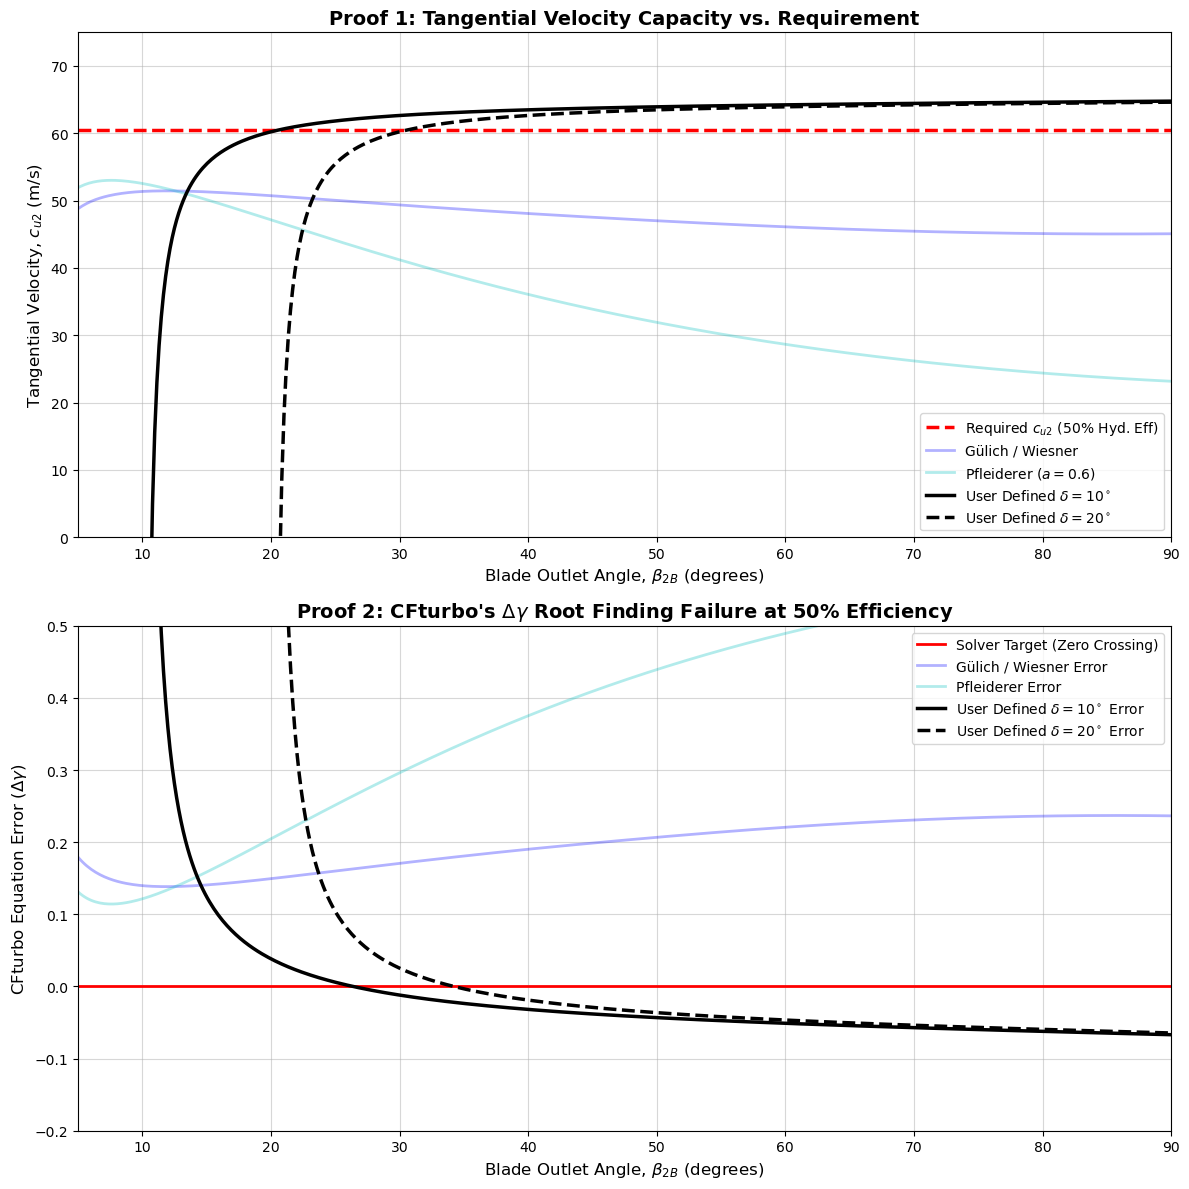

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Global Boundary Conditions
H = 200.0        # Target Head (m)
Q = 0.0003       # Flow rate (m^3/s)
n = 20000        # RPM
g = 9.81         # Gravity (m/s^2)

# 2. CFturbo / Conventional Geometry Baseline
d2 = 0.062       # Impeller outer diameter (m)
d_LE = 0.0254    # Impeller inlet (leading edge) diameter (m)
b2 = 0.001858    # Impeller width (m)
z = 6            # Number of blades

# 3. Velocity and Kinematics
u2 = np.pi * d2 * n / 60
cm2 = Q / (np.pi * d2 * b2)
epsilon = d_LE / d2  

# 4. Blade Angle Sweep (From extremely shallow 5 deg to straight radial 90 deg)
beta2B_deg = np.linspace(5, 90, 500)
beta2B_rad = np.radians(beta2B_deg)

# ==========================================
# REQUIRED EULER TANGENTIAL VELOCITY
# ==========================================
cu2_req_50 = (g * H) / (0.50 * u2)  
cu2_req_60 = (g * H) / (0.60 * u2)  

cu2_inf = u2 - cm2 / np.tan(beta2B_rad)

# ==========================================
# EMPIRICAL SLIP MODELS (Simplified for brevity in plotting)
# ==========================================
# Gülich / Wiesner
f1 = 0.98
eps_lim_GW = np.exp(-8.16 * np.sin(beta2B_rad) / z)
kw_GW = np.where(epsilon <= eps_lim_GW, 1.0, 1.0 - ((epsilon - eps_lim_GW)/(1.0 - eps_lim_GW))**3)
gamma_GW = f1 * (1.0 - np.sqrt(np.sin(beta2B_rad)) / (z**0.7)) * kw_GW
cu2_GW = u2 * gamma_GW - cm2 / np.tan(beta2B_rad)

# Pfleiderer
S_pf = (d2**2 - d_LE**2) / (8.0 * np.sin(beta2B_rad))
a_pf = 0.6  
psi_prime = a_pf * (1.0 + beta2B_deg / 60.0)
p_pf = psi_prime * ((d2/2.0)**2) / (2.0 * S_pf)
kL_pf = 1.0 / (1.0 + p_pf)
cu2_PF = cu2_inf * kL_pf

# ==========================================
# THE CFTURBO "USER DEFINED" OVERRIDES (10 deg and 20 deg)
# ==========================================
# If deviation (delta) is forced, then fluid flow angle Beta2 = Beta2B - delta.
# This forces cu2 to be calculated purely geometrically, bypassing empirical slip.
delta_10_rad = np.radians(10)
delta_20_rad = np.radians(20)

# Masking to prevent plotting negative tangent asymptotes when Beta2B < Delta
valid_10 = beta2B_deg > 10.5
valid_20 = beta2B_deg > 20.5

cu2_User10 = np.full_like(beta2B_deg, np.nan)
cu2_User20 = np.full_like(beta2B_deg, np.nan)

cu2_User10[valid_10] = u2 - cm2 / np.tan(beta2B_rad[valid_10] - delta_10_rad)
cu2_User20[valid_20] = u2 - cm2 / np.tan(beta2B_rad[valid_20] - delta_20_rad)

# Calculate Effective Gamma to plug into CFturbo's Delta Gamma Solver
gamma_User10 = np.full_like(beta2B_deg, np.nan)
gamma_User20 = np.full_like(beta2B_deg, np.nan)
gamma_User10[valid_10] = 1.0 - (u2 - cu2_User10[valid_10]) / u2
gamma_User20[valid_20] = 1.0 - (u2 - cu2_User20[valid_20]) / u2

# ==========================================
# CFTURBO ROOT SOLVER ERRORS (Delta Gamma)
# ==========================================
term_1 = cm2 / (u2 * np.tan(beta2B_rad))
req_term_50 = cu2_req_50 / u2

dg_GW = term_1 + req_term_50 - gamma_GW
dg_PF = term_1 + req_term_50 - (1.0 - (cu2_inf - cu2_PF)/u2)
dg_User10 = term_1 + req_term_50 - gamma_User10
dg_User20 = term_1 + req_term_50 - gamma_User20

# ==========================================
# PLOTTING
# ==========================================
plt.figure(figsize=(12, 12))

# --- Plot 1: Delivered c_u2 vs Required ---
plt.subplot(2, 1, 1)
plt.axhline(y=cu2_req_50, color='r', linestyle='--', linewidth=2.5, label="Required $c_{u2}$ (50% Hyd. Eff)")

plt.plot(beta2B_deg, cu2_GW, 'b-', linewidth=2, label="Gülich / Wiesner", alpha=0.3)
plt.plot(beta2B_deg, cu2_PF, 'c-', linewidth=2, label="Pfleiderer ($a=0.6$)", alpha=0.3)

plt.plot(beta2B_deg, cu2_User10, 'k-', linewidth=2.5, label="User Defined $\\delta = 10^\\circ$")
plt.plot(beta2B_deg, cu2_User20, 'k--', linewidth=2.5, label="User Defined $\\delta = 20^\\circ$")

plt.title("Proof 1: Tangential Velocity Capacity vs. Requirement", fontsize=14, fontweight='bold')
plt.xlabel("Blade Outlet Angle, $\\beta_{2B}$ (degrees)", fontsize=12)
plt.ylabel("Tangential Velocity, $c_{u2}$ (m/s)", fontsize=12)
plt.xlim(5, 90)
plt.ylim(0, 75)
plt.grid(True, alpha=0.5)
plt.legend(fontsize=10, loc='lower right')

# --- Plot 2: CFturbo's Delta Gamma Solver ---
plt.subplot(2, 1, 2)
plt.axhline(y=0, color='r', linestyle='-', linewidth=2, label="Solver Target (Zero Crossing)")

plt.plot(beta2B_deg, dg_GW, 'b-', linewidth=2, label="Gülich / Wiesner Error", alpha=0.3)
plt.plot(beta2B_deg, dg_PF, 'c-', linewidth=2, label="Pfleiderer Error", alpha=0.3)

plt.plot(beta2B_deg, dg_User10, 'k-', linewidth=2.5, label="User Defined $\\delta = 10^\\circ$ Error")
plt.plot(beta2B_deg, dg_User20, 'k--', linewidth=2.5, label="User Defined $\\delta = 20^\\circ$ Error")

plt.title("Proof 2: CFturbo's $\\Delta\\gamma$ Root Finding Failure at 50% Efficiency", fontsize=14, fontweight='bold')
plt.xlabel("Blade Outlet Angle, $\\beta_{2B}$ (degrees)", fontsize=12)
plt.ylabel("CFturbo Equation Error ($\\Delta\\gamma$)", fontsize=12)
plt.xlim(5, 90)
plt.ylim(-0.2, 0.5)
plt.grid(True, alpha=0.5)
plt.legend(fontsize=10, loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
# Linearly interpolate between 8.1 to 26 degrees for 9 points:
beta2B_interp_deg = np.linspace(8.1, 35, 9)
print("Interpolated Beta2B values for User Defined Deviation:")
for angle in beta2B_interp_deg:
    print(f"{angle:.2f} degrees")
    

Interpolated Beta2B values for User Defined Deviation:
8.10 degrees
11.46 degrees
14.82 degrees
18.19 degrees
21.55 degrees
24.91 degrees
28.27 degrees
31.64 degrees
35.00 degrees
